In [1]:
# Практика 17. Проста лінійна регресія
# Коць Артем, ІТ-42
# Варіант 9 — Суми

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr

np.random.seed(9)

variant = 9
city = "Суми"

monthly_temp = [-6, -5, 0, 9, 15, 18, 20, 19, 13, 7, 1, -4]

months = [
    "Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
    "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"
]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5),
        0,
        30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

print("Студент: Коць Артем")
print("Група: ІТ-42")
print("Варіант:", variant)
print("Місто:", city)

display(climate)

Студент: Коць Артем
Група: ІТ-42
Варіант: 9
Місто: Суми


,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Суми,Січ,-6,24,3.3
1,Суми,Лют,-5,21,3.1
2,Суми,Бер,0,17,2.1
3,Суми,Кві,9,7,0.6
4,Суми,Тра,15,3,0.0
5,Суми,Чер,18,1,1.9
6,Суми,Лип,20,0,0.7
7,Суми,Сер,19,2,0.7
8,Суми,Вер,13,7,0.1
9,Суми,Жов,7,11,2.9


In [2]:
print("Розмір DataFrame:", climate.shape)

print("\nТипи даних:")
print(climate.dtypes)

print("\nПропуски:")
print(climate.isna().sum())

Розмір DataFrame: (12, 5)

Типи даних:
місто                      str
місяць                     str
температура              int64
опалювальні_дні          int64
витрати_на_опалення    float64
dtype: object

Пропуски:
місто                  0
місяць                 0
температура            0
опалювальні_дні        0
витрати_на_опалення    0
dtype: int64


In [3]:
# Завдання 1. Проста лінійна регресія

x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

print(f"Нахил b1 = {result.slope:.3f}")
print(f"Перетин b0 = {result.intercept:.3f}")
print(f"R² = {result.rvalue ** 2:.3f}")
print(f"p-value = {result.pvalue:.6f}")

print(
    f"\nРівняння регресії:"
    f"\nвитрати ≈ {result.intercept:.3f} "
    f"+ ({result.slope:.3f}) × температура"
)

Нахил b1 = -0.112
Перетин b0 = 2.635
R² = 0.659
p-value = 0.001352

Рівняння регресії:
витрати ≈ 2.635 + (-0.112) × температура


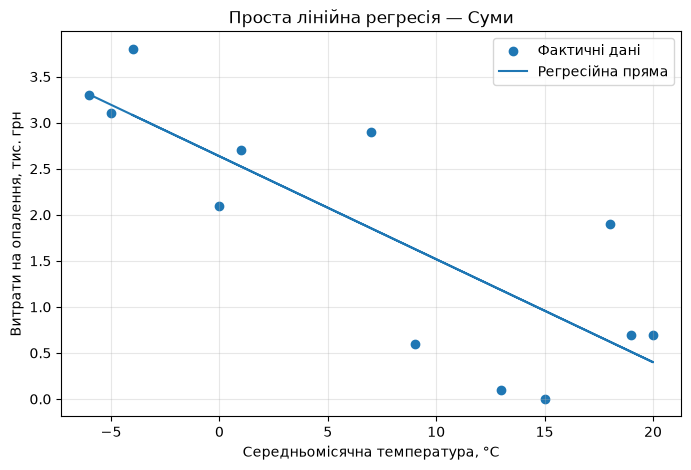

In [4]:
predicted = result.intercept + result.slope * x

plt.figure(figsize=(8, 5))

plt.scatter(x, y, label="Фактичні дані")
plt.plot(x, predicted, label="Регресійна пряма")

plt.xlabel("Середньомісячна температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title("Проста лінійна регресія — Суми")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Завдання 1. Інтерпретація моделі

Отримане рівняння простої лінійної регресії має вигляд:

`витрати ≈ b0 + b1 × температура`

де `b0` — перетин із віссю Y, а `b1` — коефіцієнт нахилу.

Коефіцієнт `b1` показує, як у середньому змінюються витрати на опалення при збільшенні середньомісячної температури на 1°C.

Для нашого набору даних нахил має негативний знак. Це логічно: при підвищенні температури потрібно менше опалювальних днів, тому витрати на опалення в середньому зменшуються.

Перетин `b0` є формальним прогнозом витрат при температурі 0°C. Його змістовна інтерпретація залежить від того, чи є 0°C типовим значенням у межах спостережених даних.

In [5]:
# Завдання 2. R² двома способами

# R² через rvalue
r2_from_r = result.rvalue ** 2

# Залишки
residuals = y - predicted

# Сума квадратів залишків
SS_residual = np.sum(residuals ** 2)

# Середнє фактичних значень
y_mean = np.mean(y)

# Загальна сума квадратів
SS_total = np.sum((y - y_mean) ** 2)

# R² через суми квадратів
r2_from_ss = 1 - SS_residual / SS_total

print(f"R² через result.rvalue² = {r2_from_r:.6f}")
print(f"R² через 1 - SSзалишків / SSзагальна = {r2_from_ss:.6f}")

print("\nПеревірка:")
print(np.isclose(r2_from_r, r2_from_ss))

R² через result.rvalue² = 0.658563
R² через 1 - SSзалишків / SSзагальна = 0.658563

Перевірка:
True


In [6]:
pearson_result = pearsonr(x, y)

r = pearson_result.statistic
r_squared = r ** 2

print(f"Коефіцієнт Пірсона r = {r:.6f}")
print(f"r² = {r_squared:.6f}")
print(f"R² регресії = {r2_from_r:.6f}")

print("\nR² = r²:", np.isclose(r_squared, r2_from_r))

Коефіцієнт Пірсона r = -0.811519
r² = 0.658563
R² регресії = 0.658563

R² = r²: True


### Інтерпретація R²

Для простої лінійної регресії отримане значення `R²` збігається зі значенням `r²` з Практики 16.

`R²` показує, яку частку варіації витрат на опалення пояснює лінійна модель із температурою як предиктором.

Наприклад, якщо `R² = 0.80`, це означало б, що приблизно 80% розкиду витрат пояснюється температурою, а близько 20% залишається непоясненим моделлю.

У нашому випадку висновок потрібно робити за фактичним значенням `R²`, отриманим вище.

In [7]:
# Завдання 3. Залишки

climate["передбачені_витрати"] = predicted
climate["залишок"] = residuals

display(
    climate[
        [
            "місяць",
            "температура",
            "витрати_на_опалення",
            "передбачені_витрати",
            "залишок"
        ]
    ].round(3)
)

,місяць,температура,витрати_на_опалення,передбачені_витрати,залишок
0,Січ,-6,3.3,3.306,-0.006
1,Лют,-5,3.1,3.194,-0.094
2,Бер,0,2.1,2.635,-0.535
3,Кві,9,0.6,1.629,-1.029
4,Тра,15,0.0,0.959,-0.959
5,Чер,18,1.9,0.623,1.277
6,Лип,20,0.7,0.400,0.300
7,Сер,19,0.7,0.512,0.188
8,Вер,13,0.1,1.182,-1.082
9,Жов,7,2.9,1.853,1.047


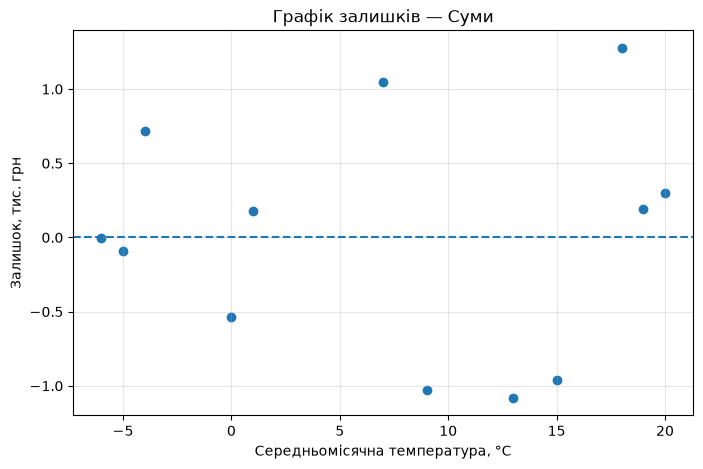

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    climate["температура"],
    climate["залишок"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Середньомісячна температура, °C")
plt.ylabel("Залишок, тис. грн")
plt.title("Графік залишків — Суми")
plt.grid(True, alpha=0.3)

plt.show()

## Аналіз графіка залишків

На графіку залишків точки розташовані по обидва боки від горизонтальної лінії `y = 0`.

Необхідно звернути увагу на розподіл залишків у різних частинах діапазону температур. Для холодних температур залишки мають один характер розподілу, а для найтепліших місяців може проявлятися систематична структура.

Це пов'язано з особливістю генерації даних. Витрати на опалення були обмежені знизу нулем за допомогою `max(cost, 0)`. Через це фактичні витрати не можуть бути від'ємними, тоді як лінійна регресія формально може передбачити від'ємні значення для достатньо високої температури.

Тому для найтепліших місяців можуть виникати позитивні залишки та помітна структура на графіку. Це показує, що навіть відносно високе `R²` саме по собі не гарантує адекватності лінійної моделі.

Графік залишків дає додаткову інформацію, якої не видно з одного числового значення `R²`: він дозволяє виявити систематичні відхилення, нелінійність або нерівномірний розкид залишків.

In [9]:
# Завдання 4. Прогноз для температури -10°C

new_temperature = -10

forecast = (
    result.intercept +
    result.slope * new_temperature
)

min_temp = climate["температура"].min()
max_temp = climate["температура"].max()

print(f"Прогнозовані витрати при температурі {new_temperature}°C:")
print(f"{forecast:.3f} тис. грн")

print(f"\nФактичний діапазон температур:")
print(f"від {min_temp}°C до {max_temp}°C")

if min_temp <= new_temperature <= max_temp:
    print("\n-10°C знаходиться всередині спостереженого діапазону.")
else:
    print("\n-10°C знаходиться ЗА межами спостереженого діапазону.")

Прогнозовані витрати при температурі -10°C:
3.753 тис. грн

Фактичний діапазон температур:
від -6°C до 20°C

-10°C знаходиться ЗА межами спостереженого діапазону.


## Завдання 4. Інтерпретація прогнозу

За рівнянням регресії прогнозовані витрати на опалення при температурі `-10°C` становлять отримане вище значення тис. грн.

Мінімальна температура у нашому наборі становить -6°C, а максимальна — 20°C.

Отже, температура -10°C знаходиться за межами спостереженого діапазону від -6°C до 20°C. Це є екстраполяцією.

Довіра до такого прогнозу повинна бути нижчою, ніж до прогнозу для температури всередині спостереженого діапазону, оскільки модель не перевірялася на даних при температурах нижче -6°C.

Лінійна залежність, яка добре працює в межах наявних даних, не обов'язково зберігається за межами цього діапазону.

In [10]:
# Завдання 5. Порівняння p-value

pearson_result = pearsonr(
    climate["температура"],
    climate["витрати_на_опалення"]
)

print(f"p-value Пірсона:   {pearson_result.pvalue:.10f}")
print(f"p-value регресії:  {result.pvalue:.10f}")

print(
    "\nРезультати дуже близькі:",
    np.isclose(
        pearson_result.pvalue,
        result.pvalue
    )
)

p-value Пірсона:   0.0013522399
p-value регресії:  0.0013522399

Результати дуже близькі: True


## Завдання 5. Чому p-value однакові?

Для простої лінійної регресії з одним предиктором перевірка нульової гіпотези про нульовий нахил:

`H0: b1 = 0`

є еквівалентною перевірці нульової гіпотези про відсутність лінійної кореляції:

`H0: r = 0`.

Обидві перевірки відповідають питанню, чи існує статистично значущий лінійний зв'язок між температурою та витратами на опалення.

Тому `p-value`, отримане через `linregress()`, і `p-value`, отримане через `pearsonr()`, для тієї самої пари змінних є однаковими або практично однаковими.

# Контрольні питання

### 1. Чому метод найменших квадратів мінімізує суму квадратів залишків?

Квадрати залишків роблять усі відхилення невід'ємними, тому позитивні та негативні помилки не можуть взаємно компенсуватися. Крім того, великі помилки отримують більшу вагу, оскільки підносяться до квадрату.

Сума квадратів має зручні математичні властивості та дозволяє однозначно знайти параметри лінійної моделі методом найменших квадратів.

### 2. Що означає коефіцієнт нахилу b1 і чим він відрізняється від r?

Коефіцієнт нахилу `b1` показує, на скільки тис. грн у середньому змінюються витрати на опалення при збільшенні температури на 1°C.

Коефіцієнт кореляції `r` не має таких одиниць вимірювання. Він показує силу та напрямок лінійного зв'язку і завжди знаходиться в межах від -1 до 1.

Отже, `b1` має змістовні одиниці вимірювання, а `r` є стандартизованим показником сили зв'язку.

### 3. Чому високий R² не гарантує адекватності лінійної моделі?

Високе `R²` показує, що модель пояснює значну частину варіації залежної змінної, але не показує структуру помилок.

Графік залишків може виявити нелінійність, систематичні відхилення, викиди або зміну розкиду залишків.

Тому для оцінки адекватності моделі потрібно аналізувати не лише `R²`, а й графік залишків.

### 4. Що змінюється при прогнозі за межами спостереженого діапазону?

Прогноз за межами спостереженого діапазону називається екстраполяцією.

Його надійність нижча, тому що модель не перевірена на таких значеннях `x`. Невідомо, чи зберігається встановлена на вибірці лінійна залежність за межами доступних даних.

У нашому випадку прогноз для `-10°C` є екстраполяцією, оскільки фактичний діапазон температур становить від -6°C до 20°C.